In [94]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [95]:
df = pd.read_csv("Exam_Score_Prediction.csv")

In [96]:
df.head()

,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,1,17,male,diploma,2.78,92.9,yes,7.4,poor,coaching,low,hard,58.9
1,2,23,other,bca,3.37,64.8,yes,4.6,average,online videos,medium,moderate,54.8
2,3,22,male,b.sc,7.88,76.8,yes,8.5,poor,coaching,high,moderate,90.3
3,4,20,other,diploma,0.67,48.4,yes,5.8,average,online videos,low,moderate,29.7
4,5,20,female,diploma,0.89,71.6,yes,9.8,poor,coaching,low,moderate,43.7


In [97]:
df.drop('student_id',axis = 1,inplace = True)

In [98]:
df.head()

,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,17,male,diploma,2.78,92.9,yes,7.4,poor,coaching,low,hard,58.9
1,23,other,bca,3.37,64.8,yes,4.6,average,online videos,medium,moderate,54.8
2,22,male,b.sc,7.88,76.8,yes,8.5,poor,coaching,high,moderate,90.3
3,20,other,diploma,0.67,48.4,yes,5.8,average,online videos,low,moderate,29.7
4,20,female,diploma,0.89,71.6,yes,9.8,poor,coaching,low,moderate,43.7


In [99]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               20000 non-null  int64  
 1   gender            20000 non-null  object 
 2   course            20000 non-null  object 
 3   study_hours       20000 non-null  float64
 4   class_attendance  20000 non-null  float64
 5   internet_access   20000 non-null  object 
 6   sleep_hours       20000 non-null  float64
 7   sleep_quality     20000 non-null  object 
 8   study_method      20000 non-null  object 
 9   facility_rating   20000 non-null  object 
 10  exam_difficulty   20000 non-null  object 
 11  exam_score        20000 non-null  float64
dtypes: float64(4), int64(1), object(7)
memory usage: 1.8+ MB


### Relationship with Target Variable (`exam_score`)

#### Numerical Features vs. `exam_score`

Let's check the correlation between numerical features and `exam_score`, and then visualize these relationships using scatter plots.

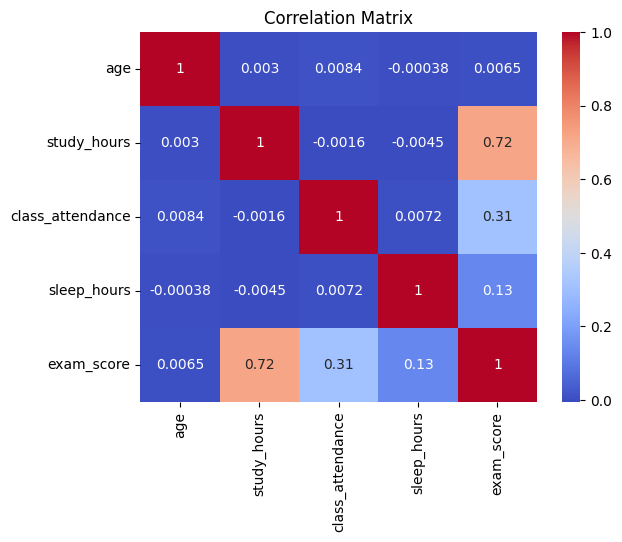

In [100]:
# Correlation matrix for numerical features
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

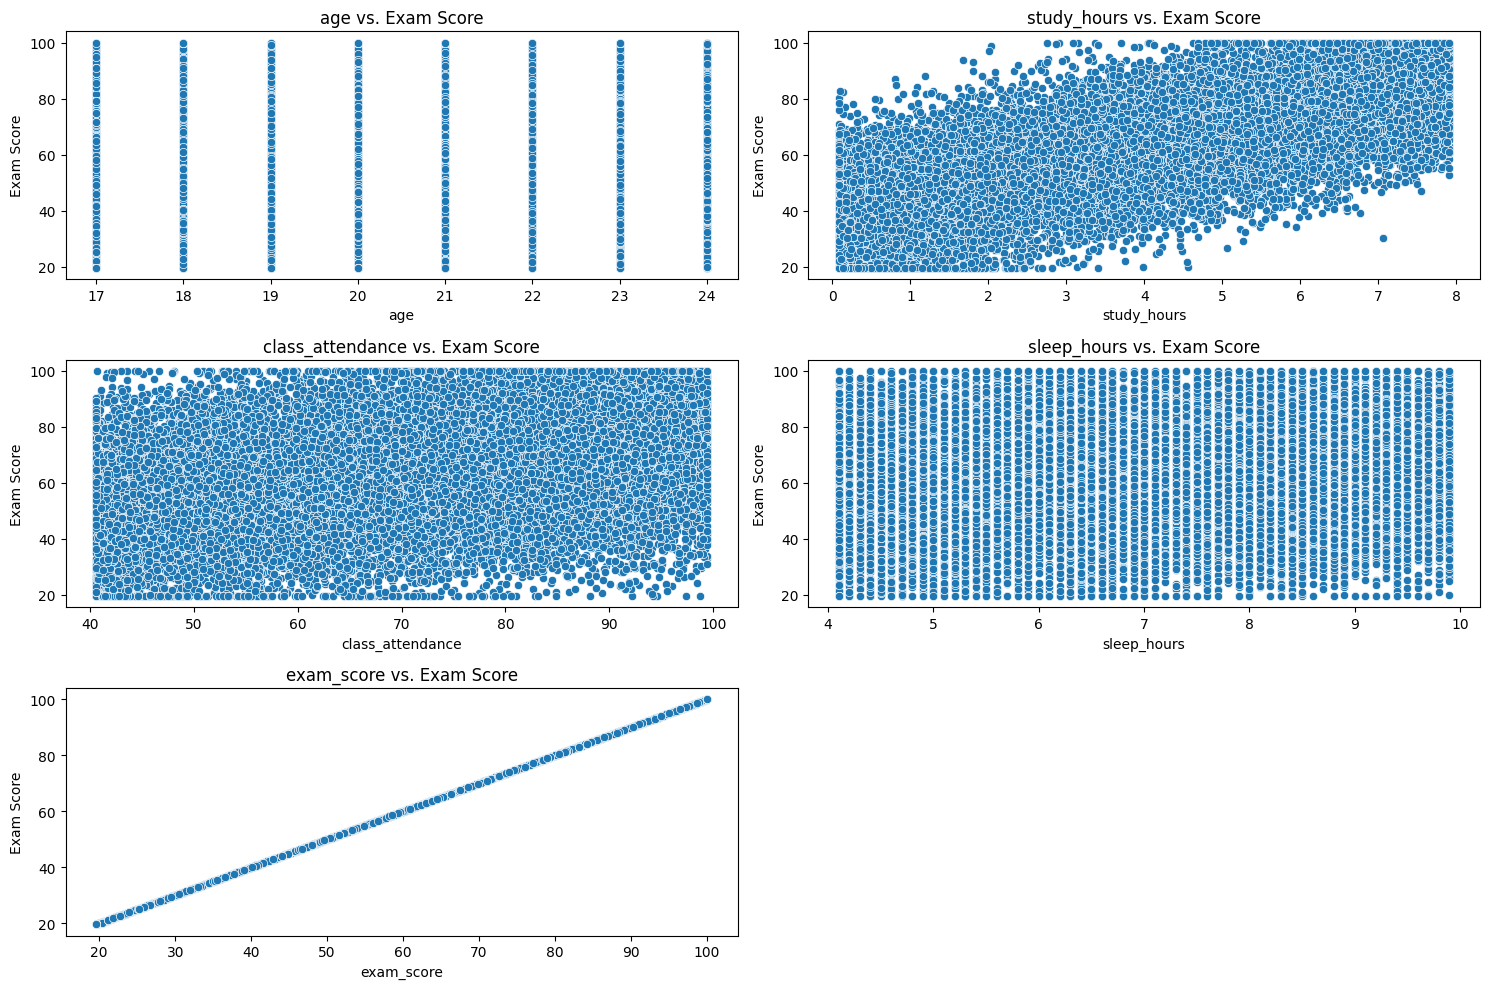

In [101]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 2, i + 1)
    sns.scatterplot(x=df[col], y=df['exam_score'])
    plt.title(f'{col} vs. Exam Score')
    plt.xlabel(col)
    plt.ylabel('Exam Score')
plt.tight_layout()
plt.show()

#### Categorical Features vs. `exam_score`

Now, let's visualize the relationship between categorical features and `exam_score` using box plots to see how the exam scores vary across different categories.

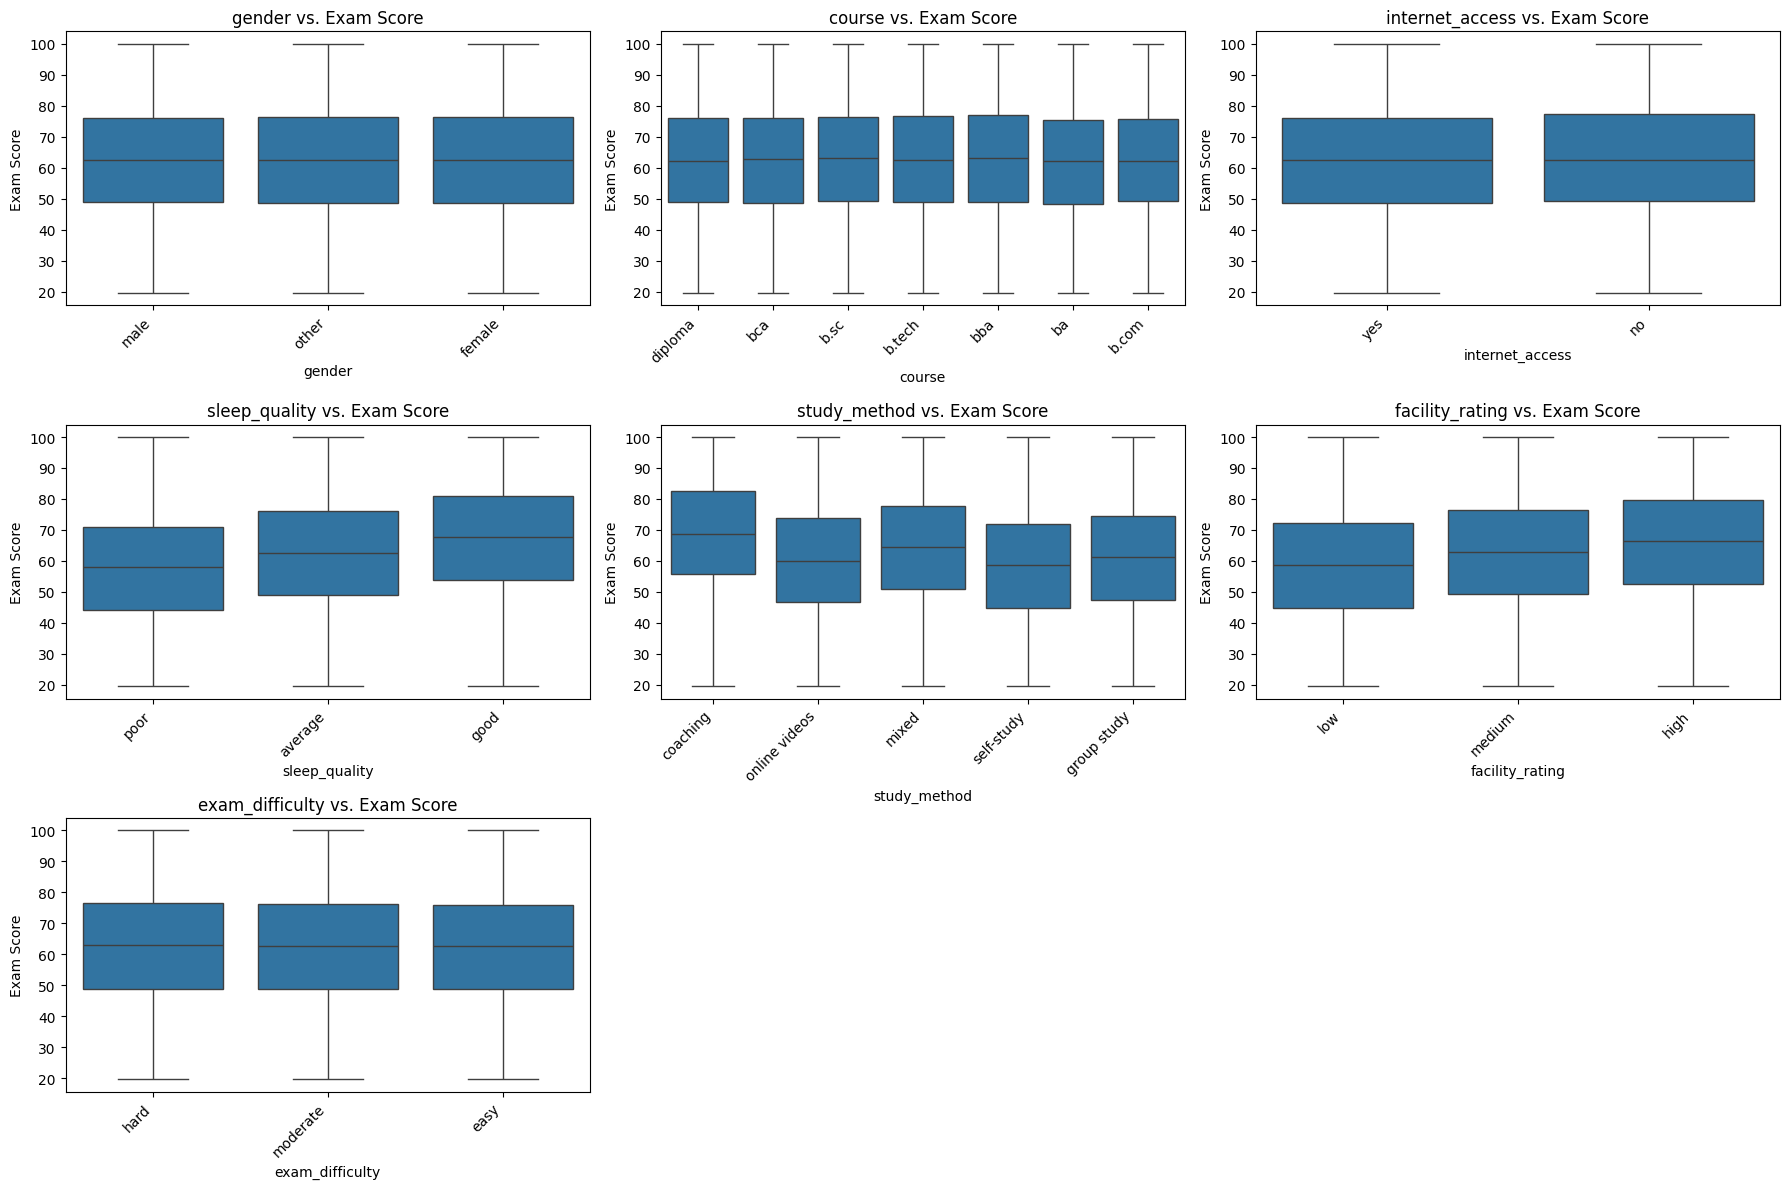

In [102]:
plt.figure(figsize=(18, 12))
for i, col in enumerate(categorical_cols):
    plt.subplot(3, 3, i + 1) # Adjust subplot grid based on number of categorical columns
    sns.boxplot(x=df[col], y=df['exam_score'])
    plt.title(f'{col} vs. Exam Score')
    plt.xlabel(col)
    plt.ylabel('Exam Score')
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Data Preprocessing: Label Encoding Revisited

First, let's identify the categorical columns and assign them to `cat_col`.

In [103]:
cat_col = df.select_dtypes(include='object').columns
print(f"Categorical columns identified: {list(cat_col)}")

Categorical columns identified: ['gender', 'course', 'internet_access', 'sleep_quality', 'study_method', 'facility_rating', 'exam_difficulty']


Now, we will apply Label Encoding to these `cat_col` columns. We'll create a new DataFrame `df_encoded` to store the results.

In [104]:
from sklearn.preprocessing import LabelEncoder

df1 = df.copy() # Create a copy of the original DataFrame

for col in cat_col:
    le = LabelEncoder()
    df1[col] = le.fit_transform(df1[col])

In [105]:
df1.head()

,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,17,1,6,2.78,92.9,1,7.4,2,0,1,1,58.9
1,23,2,5,3.37,64.8,1,4.6,0,3,2,2,54.8
2,22,1,1,7.88,76.8,1,8.5,2,0,0,2,90.3
3,20,2,6,0.67,48.4,1,5.8,0,3,1,2,29.7
4,20,0,6,0.89,71.6,1,9.8,2,0,1,2,43.7


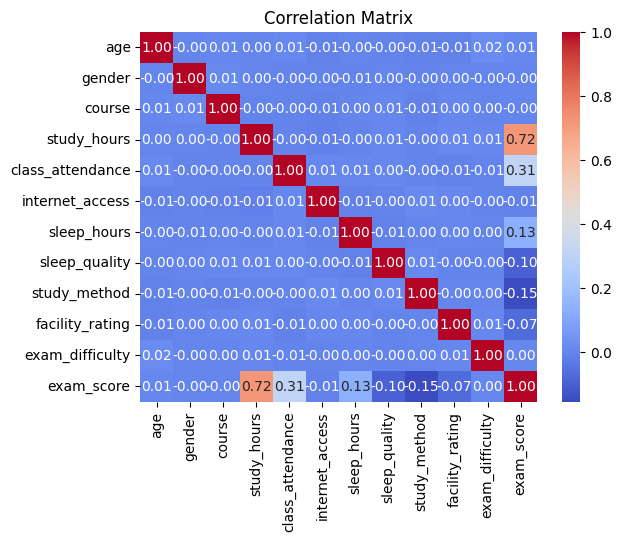

In [106]:
sns.heatmap(df1.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title('Correlation Matrix')
plt.show()

## Statistical Testing for Feature Significance

We will now perform statistical tests to identify which features have a significant relationship with the target variable `exam_score`. We'll use Pearson correlation for numerical features and ANOVA for categorical features.

In [107]:
from scipy.stats import pearsonr, f_oneway

significant_cols = []
alpha = 0.05 # Significance level

# Re-identify numerical and categorical columns from df1 (excluding exam_score itself)
# `numerical_cols` and `cat_col` from previous steps are based on original df.
# We need to re-evaluate for df1 which has all feature columns as numeric types.

# True numerical columns (originally numerical)
true_numerical_features = ['age', 'study_hours', 'class_attendance', 'sleep_hours']

# Encoded categorical columns (originally object type, now numerical after encoding)
encoded_categorical_features = [col for col in cat_col if col != 'exam_score']


print("\n--- Testing Numerical Features (Pearson Correlation) ---")
for col in true_numerical_features:
    correlation, p_value = pearsonr(df1[col], df1['exam_score'])
    print(f"Feature: {col}, Pearson Correlation: {correlation:.4f}, P-value: {p_value:.4f}")
    if p_value < alpha:
        significance = 'Significant'
        significant_cols.append(col)
    else:
        significance = 'Not Significant'
    print(f"  -> {significance}")

print("\n--- Testing Encoded Categorical Features (ANOVA) ---")
for col in encoded_categorical_features:
    # Group exam scores by categories in the current feature
    groups = [df1['exam_score'][df1[col] == category] for category in df1[col].unique()]
    f_statistic, p_value = f_oneway(*groups)
    print(f"Feature: {col}, F-statistic: {f_statistic:.4f}, P-value: {p_value:.4f}")
    if p_value < alpha:
        significance = 'Significant'
        significant_cols.append(col)
    else:
        significance = 'Not Significant'
    print(f"  -> {significance}")

print("\n--- Summary ---")
print(f"Columns with significant relationship to exam_score (p < {alpha}):")


--- Testing Numerical Features (Pearson Correlation) ---
Feature: age, Pearson Correlation: 0.0065, P-value: 0.3564
  -> Not Significant
Feature: study_hours, Pearson Correlation: 0.7178, P-value: 0.0000
  -> Significant
Feature: class_attendance, Pearson Correlation: 0.3089, P-value: 0.0000
  -> Significant
Feature: sleep_hours, Pearson Correlation: 0.1332, P-value: 0.0000
  -> Significant

--- Testing Encoded Categorical Features (ANOVA) ---
Feature: gender, F-statistic: 0.1906, P-value: 0.8265
  -> Not Significant
Feature: course, F-statistic: 0.6144, P-value: 0.7190
  -> Not Significant
Feature: internet_access, F-statistic: 1.2250, P-value: 0.2684
  -> Not Significant
Feature: sleep_quality, F-statistic: 411.7933, P-value: 0.0000
  -> Significant
Feature: study_method, F-statistic: 180.5267, P-value: 0.0000
  -> Significant
Feature: facility_rating, F-statistic: 273.7664, P-value: 0.0000
  -> Significant
Feature: exam_difficulty, F-statistic: 0.2370, P-value: 0.7890
  -> Not Sign

In [108]:
print(significant_cols)

['study_hours', 'class_attendance', 'sleep_hours', 'sleep_quality', 'study_method', 'facility_rating']


In [109]:
X = df1[['study_hours', 'class_attendance', 'sleep_hours', 'sleep_quality', 'study_method', 'facility_rating']]
# X = df1.drop('exam_score', axis=1)
y = df1['exam_score']

In [110]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [111]:
df1.shape

(20000, 12)

In [112]:
X.shape

(20000, 6)

In [113]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
dt = DecisionTreeRegressor()
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
y_train_pred = dt.predict(X_train)
train_mse = mean_squared_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)
print("Mean Squared Error:", mse)
print("R-squared:", r2)
print("Train Mean Squared Error:", train_mse)
print("Train R-squared:", train_r2)

Mean Squared Error: 217.21390196725
R-squared: 0.39274332425097525
Train Mean Squared Error: 0.0
Train R-squared: 1.0


In [116]:
from sklearn.ensemble import  AdaBoostRegressor
ab_model = AdaBoostRegressor()
ab_model.fit(X_train, y_train)

AdaBoostRegressor()

In [117]:
y_ab_pred = ab_model.predict(X_test)
mse = mean_squared_error(y_test, y_ab_pred)
r2 = r2_score(y_test, y_ab_pred)
y_train_pred = ab_model.predict(X_train)
train_mse = mean_squared_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

In [118]:
print("Mean Squared Error:", mse)
print("R-squared:", r2)
print("Train Mean Squared Error:", train_mse)
print("Train R-squared:", train_r2)

Mean Squared Error: 118.77706702924777
R-squared: 0.6679394540305478
Train Mean Squared Error: 116.95976616564009
Train R-squared: 0.6728056927682308


In [119]:
from xgboost import XGBRFRegressor
xgb_model = XGBRFRegressor(random_state=42)
xgb_model.fit(X_train, y_train)

XGBRFRegressor(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bytree=None, device=None,
               early_stopping_rounds=None, enable_categorical=False,
               eval_metric=None, feature_types=None, feature_weights=None,
               gamma=None, grow_policy=None, importance_type=None,
               interaction_constraints=None, max_bin=None,
               max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=None, max_leaves=None,
               min_child_weight=None, missing=nan, monotone_constraints=None,
               multi_strategy=None, n_estimators=None, n_jobs=None,
               num_parallel_tree=None, objective='reg:squarederror',
               random_state=42, ...)

In [121]:
y_xgb_pred = xgb_model.predict(X_test)
mse = mean_squared_error(y_test, y_xgb_pred)
r2 = r2_score(y_test, y_xgb_pred)
y_train_pred = xgb_model.predict(X_train)
train_mse = mean_squared_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

In [122]:
print("Mean Squared Error:", mse)
print("R-squared:", r2)
print("Train Mean Squared Error:", train_mse)
print("Train R-squared:", train_r2)

Mean Squared Error: 119.64829485852219
R-squared: 0.6655037953980493
Train Mean Squared Error: 113.49163065337072
Train R-squared: 0.6825077829273014


## Hyperparameter Tuning with GridSearchCV for XGBRFRegressor

Let's use `GridSearchCV` to find the best combination of hyperparameters for the `XGBRFRegressor` to potentially improve its performance.

In [123]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search
param_grid = {
    'n_estimators': [100, 200, 300], # Number of boosting rounds
    'max_depth': [3, 5, 7],         # Maximum depth of a tree
    'min_child_weight': [1, 3, 5],  # Minimum sum of instance weight (hessian) needed in a child
    'subsample': [0.7, 0.8, 0.9],   # Subsample ratio of the training instance
    'colsample_bytree': [0.7, 0.8, 0.9] # Subsample ratio of columns when constructing each tree
}

# Initialize the XGBRFRegressor model
xgb = XGBRFRegressor(random_state=42)

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=xgb,
                           param_grid=param_grid,
                           scoring='neg_mean_squared_error', # Optimize for lower MSE
                           cv=3, # 3-fold cross-validation
                           n_jobs=-1, # Use all available cores
                           verbose=2)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

# Print the best parameters and best score
print(f"\nBest parameters found: {grid_search.best_params_}")
print(f"Best negative MSE score: {grid_search.best_score_:.4f}")
print(f"Best RMSE score: {np.sqrt(-grid_search.best_score_):.4f}")

Fitting 3 folds for each of 243 candidates, totalling 729 fits

Best parameters found: {'colsample_bytree': 0.9, 'max_depth': 7, 'min_child_weight': 1, 'n_estimators': 300, 'subsample': 0.7}
Best negative MSE score: -114.9781
Best RMSE score: 10.7228


## Training XGBRFRegressor with Best Parameters

Now, let's train a new `XGBRFRegressor` model using the best hyperparameters found by `GridSearchCV`.

In [124]:
# Get the best model from GridSearchCV
best_xgb_model = grid_search.best_estimator_

# Make predictions on the test set using the best model
y_xgb_tuned_pred = best_xgb_model.predict(X_test)

# Evaluate the tuned model on the test set
mse_tuned = mean_squared_error(y_test, y_xgb_tuned_pred)
r2_tuned = r2_score(y_test, y_xgb_tuned_pred)

# Make predictions on the training set using the best model
y_train_xgb_tuned_pred = best_xgb_model.predict(X_train)

# Evaluate the tuned model on the training set
train_mse_tuned = mean_squared_error(y_train, y_train_xgb_tuned_pred)
train_r2_tuned = r2_score(y_train, y_train_xgb_tuned_pred)

print("\n--- Tuned XGBRFRegressor Performance ---")
print(f"Test Mean Squared Error (Tuned): {mse_tuned:.4f}")
print(f"Test R-squared (Tuned): {r2_tuned:.4f}")
print(f"Train Mean Squared Error (Tuned): {train_mse_tuned:.4f}")
print(f"Train R-squared (Tuned): {train_r2_tuned:.4f}")


--- Tuned XGBRFRegressor Performance ---
Test Mean Squared Error (Tuned): 119.0847
Test R-squared (Tuned): 0.6671
Train Mean Squared Error (Tuned): 108.9973
Train R-squared (Tuned): 0.6951


## Saving Model and Preprocessors for Deployment

We will now save the `best_xgb_model` and the `LabelEncoder` objects for the categorical features to `.pkl` files. This allows for easy loading and consistent preprocessing of new data in a deployment environment.

In [125]:
import joblib
from sklearn.preprocessing import LabelEncoder

# Define a directory for saving files (optional, but good practice)
save_dir = './deployment_assets'
import os
os.makedirs(save_dir, exist_ok=True)

# 1. Save the best XGBoost model
model_filename = os.path.join(save_dir, 'best_xgb_regressor.pkl')
joblib.dump(best_xgb_model, model_filename)
print(f"Saved best XGBoost Regressor model to {model_filename}")

# 2. Save LabelEncoders for categorical features used in the model
# These are: 'sleep_quality', 'study_method', 'facility_rating'

categorical_features_in_model = ['sleep_quality', 'study_method', 'facility_rating']

for col in categorical_features_in_model:
    le = LabelEncoder()
    # Fit the encoder on the original data's column to capture all categories
    le.fit(df[col])
    encoder_filename = os.path.join(save_dir, f'{col}_label_encoder.pkl')
    joblib.dump(le, encoder_filename)
    print(f"Saved LabelEncoder for '{col}' to {encoder_filename}")

print("\nAll necessary files saved for deployment.")

Saved best XGBoost Regressor model to ./deployment_assets/best_xgb_regressor.pkl
Saved LabelEncoder for 'sleep_quality' to ./deployment_assets/sleep_quality_label_encoder.pkl
Saved LabelEncoder for 'study_method' to ./deployment_assets/study_method_label_encoder.pkl
Saved LabelEncoder for 'facility_rating' to ./deployment_assets/facility_rating_label_encoder.pkl

All necessary files saved for deployment.
